In [2]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

In [3]:
def roll_dice(n=0):
    if n == 0:
        return np.random.ranint(1,7) + np.random.ranint(1,7)
    return np.random.ranint(1,7, size=n) + np.random.ranint(1,7, size=n)

In [4]:
def p1_stand_win_chance(x):
    # Give p1 score 0<=x<=20 it finds the chance of p1 winnning, tieing, losing
    rolls = np.array([i for i in range(2, 13)])
    roll_probs = np.array([1/36, 2/36, 3/36, 4/36, 5/36, 6/36, 5/36, 4/36, 3/36, 2/36, 1/36])
    chances = {1:0, 0:0, -1:0} # 1 is win, 0 is tie, -1 is loss
    cur = {0: 1}

    while cur:
        d = defaultdict(float)
        for r, p in cur.items():
            next = r + rolls
            next[next > 21] = -3
            next[next > x] = -1
            next[next == x] = -2
            for i in range(len(next)):
                val = next[i]
                if val == -1:
                    chances[-1] += roll_probs[i] * p
                elif val == -2:
                    chances[0] += roll_probs[i] * p
                elif val == -3:
                    chances[1] += roll_probs[i] * p
                else:
                    d[val] += roll_probs[i] * p
        cur = d
    return chances

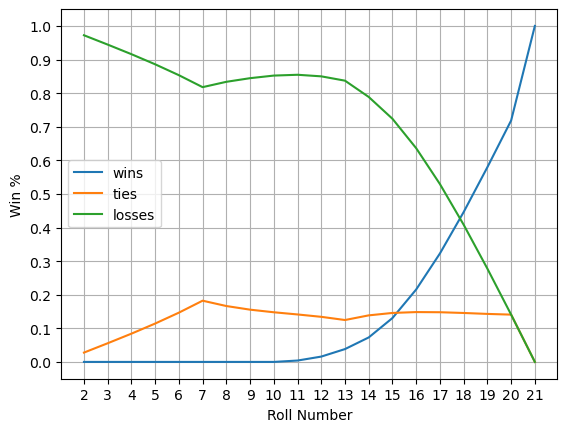

In [5]:
rolls = [i for i in range(2, 21)]
wins = []
ties = []
losses = []

for roll in rolls:
    chances = p1_stand_win_chance(roll)
    wins.append(chances[1])
    ties.append(chances[0])
    losses.append(chances[-1])
    # print(roll, wins[-1], ties[-1], losses[-1])
wins.append(1)
ties.append(0)
losses.append(0)

plt.plot(rolls + [21], wins, label="wins")
plt.plot(rolls + [21], ties, label="ties")
plt.plot(rolls + [21], losses, label="losses")
plt.legend()
plt.grid()
plt.xlabel("Roll Number")
plt.ylabel("Win %")
plt.xticks(rolls + [21])
plt.yticks([i/10 for i in range(0, 11)])
plt.show()

In [ ]:
def dynamic_find_win_p1(x):
    if x < 0 or x > 21:
        raise ValueError("x must be between 0 and 21")

    rolls = np.arange(2, 13)
    roll_probs = np.array([1,2,3,4,5,6,5,4,3,2,1]) / 36

    odds = {i: {1: 0, 0: 0, -1: 1} for i in range(22, 34)}
    odds[21] = {1: 1, 0: 0, -1: 0}

    stand_odds = {i: p1_stand_win_chance(i) for i in range(0, 21)}

    for cur in range(20, -1, -1):
        roll_odd = {1: 0, 0: 0, -1: 0}

        for roll, prob in zip(rolls, roll_probs):
            result = odds[cur + roll]
            for outcome in [1, 0, -1]:
                roll_odd[outcome] += prob * result[outcome]

        stand_odd = stand_odds[cur]
        odds[cur] = stand_odd if stand_odd[1] > roll_odd[1] else roll_odd

    return odds[x]

dynamic_find_win_p1(0)

{1: np.float64(0.40184464217375515),
 0: np.float64(0.0995006589395298),
 -1: np.float64(0.4986546988867151)}